In [1]:

# Import Library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [7]:
# Sesuaikan path ini jika kamu menaruhnya di dalam folder UTS_MachineLearning
file_path = r'Gaming_Academic_Performance.csv'\

# Load Dataset
df = pd.read_csv(file_path)

# Tampilkan 5 data teratas dan nama kolom
print("Daftar Kolom dalam Dataset:")
print(df.columns.tolist())
display(df.head())

Daftar Kolom dalam Dataset:
['student_id', 'age', 'gender', 'gaming_hours', 'study_hours', 'sleep_hours', 'attendance', 'gaming_genre', 'social_activity', 'device_usage', 'reaction_time_ms', 'addiction_score', 'stress_level', 'grades']


,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000


In [8]:
# ==============================================================================
# PENTING: Ubah 'TARGET_KOLOM' menjadi nama kolom target di datasetmu!
# Contoh: Jika targetnya adalah 'Academic_Performance', ganti teks di bawah.
# ==============================================================================
target_col = 'stress_level' \

# 1. CLEANING: Menangani missing values (nilai kosong)
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Isi data angka yang kosong dengan Median
if len(num_cols) > 0:
    imputer_num = SimpleImputer(strategy='median')
    df[num_cols] = imputer_num.fit_transform(df[num_cols])

# Isi data teks yang kosong dengan Modus (nilai yang sering muncul)
if len(cat_cols) > 0:
    imputer_cat = SimpleImputer(strategy='most_frequent')
    df[cat_cols] = imputer_cat.fit_transform(df[cat_cols])

# 2. ENCODING: Pisahkan fitur (X) dan target (y)
X = df.drop(target_col, axis=1)

# Ubah fitur kategori menjadi angka (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

# Ubah target menjadi angka (Label Encoding) jika masih berbentuk teks
le = LabelEncoder()
y = le.fit_transform(df[target_col])

# 3. SPLIT & NORMALISASI
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Preprocessing Selesai. Ukuran Data Latih:", X_train.shape)

Preprocessing Selesai. Ukuran Data Latih: (6400, 15)


C:\Users\bhisma\AppData\Local\Temp\ipykernel_14980\458878070.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [9]:
# Inisialisasi Model KNN dan Decision Tree
models = {
    "K-Nearest Neighbors (KNN)": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42)
}

results = {}
predictions = {}

# Proses Training dan Evaluasi
for name, model in models.items():
    # Latih model
    model.fit(X_train, y_train)
    
    # Prediksi
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    
    # Simpan Metrik (Gunakan average='weighted' agar aman untuk data multikelas)
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, y_pred, average='weighted', zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, average='weighted', zero_division=0)
    }
    print(f"✅ Model {name} selesai dilatih.")

# Jadikan DataFrame agar rapi
df_results = pd.DataFrame(results).T
display(df_results)

✅ Model K-Nearest Neighbors (KNN) selesai dilatih.
✅ Model Decision Tree selesai dilatih.


,Accuracy,Precision,Recall,F1-Score
K-Nearest Neighbors (KNN),0.879375,0.878540,0.879375,0.877325
Decision Tree,0.998750,0.998755,0.998750,0.998748


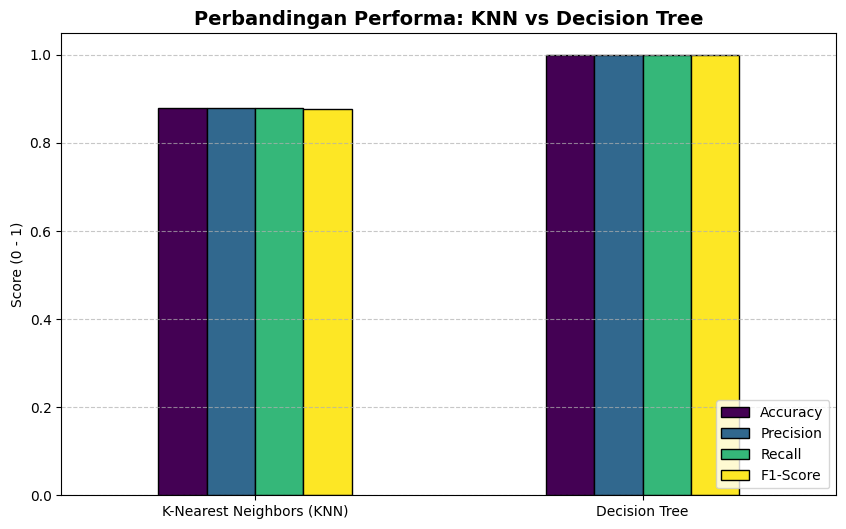

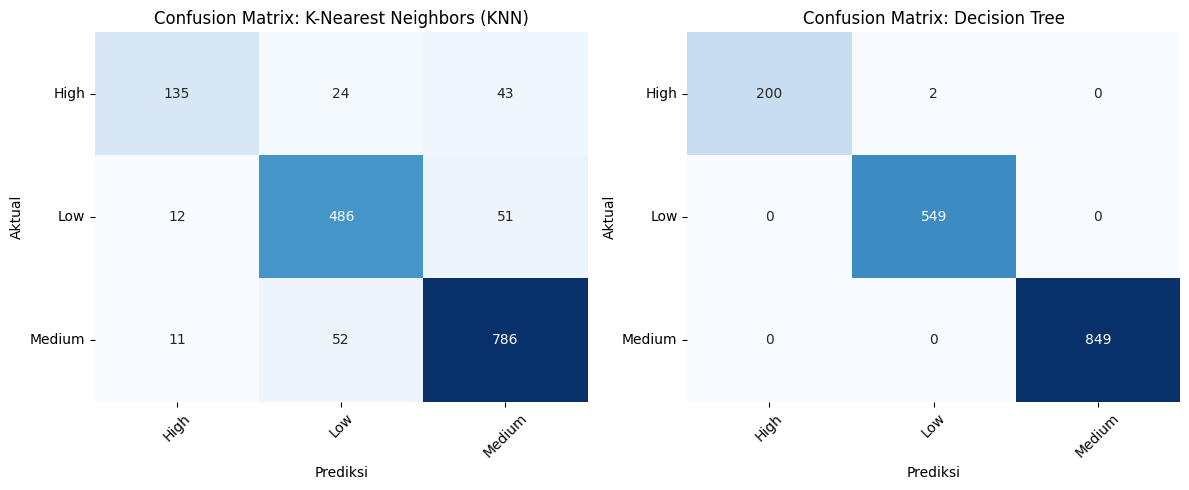

In [10]:
# 1. Bar Chart Perbandingan Metrik
df_results.plot(kind='bar', figsize=(10, 6), colormap='viridis', edgecolor='black')
plt.title("Perbandingan Performa: KNN vs Decision Tree", fontsize=14, fontweight='bold')
plt.ylabel("Score (0 - 1)")
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 2. Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f"Confusion Matrix: {name}")
    axes[i].set_xlabel("Prediksi")
    axes[i].set_ylabel("Aktual")
    # Ganti label angka ke nama asli (jika di-encode)
    axes[i].set_xticklabels(le.classes_, rotation=45)
    axes[i].set_yticklabels(le.classes_, rotation=0)

plt.tight_layout()
plt.show()